# PCA aplicado

**Tema:** Aprendizado Não Supervisionado › Redução de Dimensionalidade

O tema 2 implementou PCA do zero. Aqui o foco é **usar** PCA com critério:
conferir a implementação pela SVD contra o `scikit-learn`, escolher o
número de componentes, ver o estrago da falta de padronização, usar PCA
dentro de um `Pipeline` e — o experimento mais importante do notebook —
construir um caso em que PCA **piora** um modelo supervisionado.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_circles
from sklearn.decomposition import PCA, KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(54)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. PCA pela SVD, conferido contra o `scikit-learn`

In [2]:
digitos = load_digits()
X, y = digitos.data, digitos.target
Xc = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
var_nossa = s ** 2 / (len(X) - 1)
razao_nossa = var_nossa / var_nossa.sum()

pca = PCA().fit(X)
print("variância explicada (5 primeiros) — SVD:", razao_nossa[:5].round(4))
print("variância explicada (5 primeiros) — sklearn:", pca.explained_variance_ratio_[:5].round(4))
# componentes iguais a menos do sinal
mesmo_sub = np.allclose(np.abs(Vt[:5]), np.abs(pca.components_[:5]), atol=1e-6)
print("componentes iguais a menos do sinal?", mesmo_sub)

variância explicada (5 primeiros) — SVD: [0.1489 0.1362 0.1179 0.0841 0.0578]
variância explicada (5 primeiros) — sklearn: [0.1489 0.1362 0.1179 0.0841 0.0578]
componentes iguais a menos do sinal? True


## 2. O exemplo numérico do `teoria.pdf`

Variâncias 4 e 3, covariância 2: o texto calculou $\lambda_1 \approx 5{,}56$,
$\lambda_2 \approx 1{,}44$, primeiro componente com 79,4% da variância e
autovetor $\approx (0{,}788;\ 0{,}615)$.

In [3]:
S = np.array([[4.0, 2.0], [2.0, 3.0]])
autoval, autovec = np.linalg.eigh(S)
ordem = np.argsort(autoval)[::-1]
autoval, autovec = autoval[ordem], autovec[:, ordem]
v1 = autovec[:, 0] * np.sign(autovec[0, 0])  # convenção de sinal: 1ª coordenada positiva
print(f"autovalores: {autoval.round(3)}  -> fração do 1º: {autoval[0] / autoval.sum():.3f}")
print(f"primeiro autovetor: {v1.round(3)}")

# conferindo com dados simulados com essa covariância
amostra = rng.multivariate_normal([0, 0], S, 20000)
p2 = PCA().fit(amostra)
print(f"PCA em 20 mil pontos simulados: {p2.explained_variance_.round(2)}")

autovalores: [5.562 1.438]  -> fração do 1º: 0.795
primeiro autovetor: [0.788 0.615]
PCA em 20 mil pontos simulados: [5.64 1.44]


## 3. Quantos componentes? Quatro critérios

In [4]:
acum = np.cumsum(pca.explained_variance_ratio_)
k90, k95 = np.searchsorted(acum, 0.90) + 1, np.searchsorted(acum, 0.95) + 1
pca_corr = PCA().fit(StandardScaler().fit_transform(X))
kaiser = int((pca_corr.explained_variance_ > 1).sum())
print(f"90% da variância: {k90} componentes | 95%: {k95} componentes")
print(f"regra de Kaiser (matriz de correlação): {kaiser} componentes")

erros = []
for k in [2, 5, 10, 20, 30, 40, 64]:
    p = PCA(n_components=k).fit(X)
    rec = p.inverse_transform(p.transform(X))
    erros.append((k, np.mean((X - rec) ** 2), pca.explained_variance_[k:].sum()))
print("\nk | EQM de reconstrução | soma dos autovalores descartados / nº de colunas")
for k, eqm, desc in erros:
    print(f"{k:>2d} | {eqm:>19.3f} | {desc * (len(X) - 1) / len(X) / X.shape[1]:>10.3f}")

90% da variância: 21 componentes | 95%: 29 componentes
regra de Kaiser (matriz de correlação): 17 componentes



k | EQM de reconstrução | soma dos autovalores descartados / nº de colunas
 2 |              13.421 |     13.421
 5 |               8.542 |      8.542
10 |               4.914 |      4.914
20 |               1.984 |      1.984
30 |               0.768 |      0.768
40 |               0.221 |      0.221
64 |               0.000 |      0.000


A última coluna confere a identidade do `teoria.pdf`: o erro de
reconstrução é a soma dos autovalores descartados (aqui dividida pelo
número de colunas e ajustada de $n-1$ para $n$, para ficar na mesma escala
do erro quadrático médio).

## 4. Escala: o componente que "explica 99%" de nada

Uma base de clientes com renda em reais e três proporções entre 0 e 1.

In [5]:
n = 1000
fator = rng.normal(size=n)                         # um fator latente de "engajamento"
base = pd.DataFrame({
    "renda": rng.lognormal(np.log(6000), 0.5, n),
    "pct_app": (0.5 + 0.15 * fator + rng.normal(0, 0.05, n)).clip(0, 1),
    "pct_recorrente": (0.4 + 0.12 * fator + rng.normal(0, 0.05, n)).clip(0, 1),
    "pct_promocao": (0.3 - 0.10 * fator + rng.normal(0, 0.05, n)).clip(0, 1),
})
for nome, dados in [("sem padronizar", base), ("padronizado", StandardScaler().fit_transform(base))]:
    p = PCA().fit(dados)
    cargas = pd.Series(p.components_[0], index=base.columns)
    cargas *= np.sign(cargas.iloc[np.abs(cargas).argmax()])
    print(f"{nome:>15s}: PC1 explica {p.explained_variance_ratio_[0]:.1%} | "
          f"cargas do PC1: {cargas.round(3).to_dict()}")

 sem padronizar: PC1 explica 100.0% | cargas do PC1: {'renda': 1.0, 'pct_app': 0.0, 'pct_recorrente': 0.0, 'pct_promocao': -0.0}
    padronizado: PC1 explica 68.1% | cargas do PC1: {'renda': 0.107, 'pct_app': 0.579, 'pct_recorrente': 0.576, 'pct_promocao': -0.567}


**Leitura esperada:** sem padronizar, o PC1 é a renda sozinha, com uma
"variância explicada" enganosamente alta. Padronizado, o PC1 captura o
fator de engajamento comum às três proporções (com `pct_promocao` em
sentido oposto), e a renda — independente delas — fica para outro
componente.

## 5. PCA como pré-processamento: n_components é hiperparâmetro

In [6]:
pipe = Pipeline([("escala", StandardScaler()), ("pca", PCA()),
                 ("modelo", LogisticRegression(max_iter=3000))])
busca = GridSearchCV(pipe, {"pca__n_components": [5, 10, 20, 30, 40, 64]}, cv=5,
                     scoring="accuracy").fit(X, y)
res = pd.DataFrame(busca.cv_results_)[["param_pca__n_components", "mean_test_score",
                                       "mean_fit_time"]]
print(res.round(4).to_string(index=False))
print(f"\nmelhor n_components: {busca.best_params_['pca__n_components']}")

 param_pca__n_components  mean_test_score  mean_fit_time
                       5           0.7713         0.1478
                      10           0.8403         0.1503
                      20           0.8993         0.1414
                      30           0.9065         0.1399
                      40           0.9138         0.1637
                      64           0.9199         0.1320

melhor n_components: 64


A acurácia sobe rápido até ~20–30 componentes e depois cresce pouco (a
melhor é com todos os 64). O ganho de PCA aqui seria de custo — metade
das colunas por cerca de 1 ponto de acurácia —, não de acurácia: o caso
mais comum na prática, e uma troca que é decisão de negócio, não de
estatística.

## 6. Quando PCA atrapalha: o sinal está na direção de pouca variância

Um problema de detecção de falha: 10 sensores dominados por dois fatores
de processo (turno e lote) com muita variância, e a falha deixa uma
assinatura **sutil** num contraste entre dois sensores.

In [7]:
n = 2000
falha = rng.random(n) < 0.3
turno = rng.normal(0, 3, n)        # variação grande e irrelevante
lote = rng.normal(0, 2, n)         # idem
sensores = np.column_stack([turno + rng.normal(0, 0.3, n) for _ in range(5)] +
                           [lote + rng.normal(0, 0.3, n) for _ in range(5)])
sensores[:, 0] += 0.5 * falha      # a falha empurra o sensor 0 para cima...
sensores[:, 1] -= 0.5 * falha      # ...e o sensor 1 para baixo: sinal num contraste

def acc(pipeline):
    return cross_val_score(pipeline, sensores, falha, cv=5, scoring="roc_auc").mean()

print(f"AUC sem PCA              : {acc(Pipeline([('m', LogisticRegression())])):.3f}")
for k in [1, 2, 3, 5, 8]:
    print(f"AUC com PCA ({k} componentes): "
          f"{acc(Pipeline([('pca', PCA(k)), ('m', LogisticRegression())])):.3f}")
print("\nvariância explicada pelos componentes:",
      PCA().fit(sensores).explained_variance_ratio_.round(3))

AUC sem PCA              : 0.954
AUC com PCA (1 componentes): 0.521
AUC com PCA (2 componentes): 0.494
AUC com PCA (3 componentes): 0.955


AUC com PCA (5 componentes): 0.955


AUC com PCA (8 componentes): 0.954

variância explicada pelos componentes: [0.688 0.299 0.003 0.001 0.001 0.001 0.001 0.001 0.001 0.001]


**Leitura esperada:** com 1 ou 2 componentes, o modelo é quase aleatório
(AUC perto de 0,5): o PCA guardou turno e lote, que explicam quase toda a
variância, e jogou fora o contraste sensor 0 − sensor 1, que carrega a
falha. O desempenho só volta quando se mantêm componentes suficientes
para incluir essa direção de pouca variância. PCA não sabe qual é o alvo.

## 7. Kernel PCA: componentes não lineares

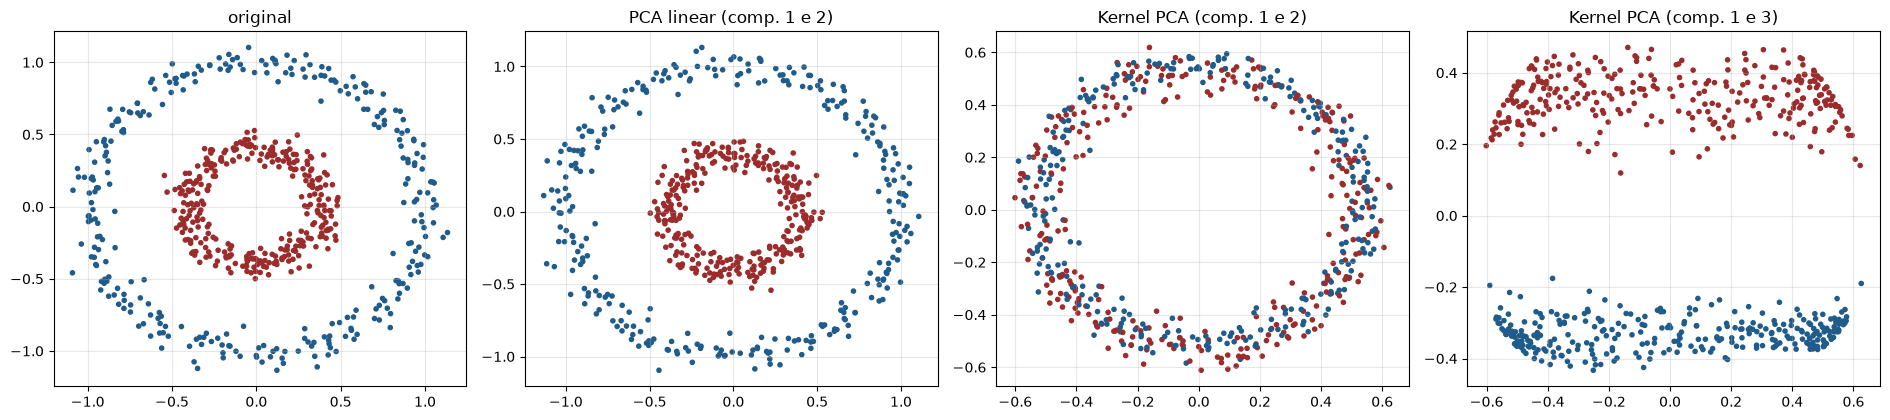

 PCA linear — AUC usando os k primeiros componentes: k=1: 0.476, k=2: 0.435
 Kernel PCA — AUC usando os k primeiros componentes: k=1: 0.481, k=2: 0.507, k=3: 1.000


In [8]:
Xc2, yc2 = make_circles(n_samples=600, factor=0.4, noise=0.06, random_state=0)
Z_lin = PCA(2).fit_transform(Xc2)
Z_ker = KernelPCA(3, kernel="rbf", gamma=2).fit_transform(Xc2)
fig, axes = plt.subplots(1, 4, figsize=(19, 4.3))
paineis = [(Xc2, "original"), (Z_lin, "PCA linear (comp. 1 e 2)"),
           (Z_ker[:, :2], "Kernel PCA (comp. 1 e 2)"), (Z_ker[:, [0, 2]], "Kernel PCA (comp. 1 e 3)")]
for ax, (Z, tit) in zip(axes, paineis):
    ax.scatter(Z[:, 0], Z[:, 1], c=np.where(yc2 == 1, VERMELHO, AZUL), s=9)
    ax.set_title(tit)
plt.tight_layout(); plt.show()
for nome, Z in [("PCA linear", Z_lin), ("Kernel PCA", Z_ker)]:
    aucs = [cross_val_score(LogisticRegression(), Z[:, :k], yc2, cv=5, scoring="roc_auc").mean()
            for k in range(1, Z.shape[1] + 1)]
    print(f"{nome:>11s} — AUC usando os k primeiros componentes: "
          + ", ".join(f"k={k}: {a:.3f}" for k, a in enumerate(aucs, start=1)))

**Leitura esperada:** nenhuma projeção linear separa os anéis. O Kernel
PCA separa perfeitamente — mas no **3º** componente: os dois primeiros
descrevem a posição angular ao redor dos anéis (o gráfico dos
componentes 1 e 2 ainda é um anel, com as classes misturadas). É a mesma
lição da seção anterior: Kernel PCA também é não supervisionado, e a
ordem dos componentes segue a variância no espaço do kernel, não a
utilidade para o alvo.

## 8. Escala de produção: PCA completo vs. randomizado

In [9]:
# 30 mil linhas, 800 colunas com estrutura de posto 60 mais ruído
X_grande = (rng.normal(size=(30000, 60)) @ rng.normal(size=(60, 800))
            + rng.normal(size=(30000, 800)) * 0.5)
for solver in ["full", "randomized"]:
    t0 = time.perf_counter()
    p = PCA(n_components=20, svd_solver=solver, random_state=0).fit(X_grande)
    print(f"{solver:>10s}: {time.perf_counter() - t0:5.2f}s  "
          f"variância explicada por 20 comp.: {p.explained_variance_ratio_.sum():.4f}")

      full:  3.37s  variância explicada por 20 comp.: 0.4404


randomized:  1.18s  variância explicada por 20 comp.: 0.4390


## O que levar deste notebook

- A SVD da matriz centrada entrega os componentes; o sinal de cada um é
  arbitrário.
- Variância acumulada, Kaiser, reconstrução e desempenho no uso final são
  critérios complementares para escolher $k$.
- Sem padronizar, o PC1 é a coluna de maior unidade — com uma "variância
  explicada" que engana.
- Em pipelines, `n_components` é hiperparâmetro. E PCA pode descartar
  justamente a direção preditiva, porque ignora o alvo.

→ Próximo: **t-SNE e métodos de manifold**, a família que troca variância
global por vizinhança local.